In [1]:
import numpy             as np
import matplotlib.pyplot as plt
import seaborn           as sns
import pandas            as pd
import os
import sys

# Assuming the `bin` directory is in the user's home directory
# For sqs
home_directory = os.path.expanduser("~")
bin_directory = os.path.join(home_directory, "bin")
os.environ["PATH"] += os.pathsep + bin_directory

from ase.build                                         import sort
from pymatgen.core.surface                             import generate_all_slabs
from pymatgen.io.vasp.inputs                           import Poscar
from pymatgen.core.structure                           import Structure
from pymatgen.core.lattice                             import Lattice
from pymatgen.transformations.advanced_transformations import SQSTransformation
from pymatgen.core.structure                           import Structure, Lattice

sys.path.append('../../UCL/m3gnet')
import ML_library as MLL

sns.set_theme()

In [2]:
# Define name of folder and path to reference POSCAR
general_folder = 'input/BiSI'
path_to_POSCAR = 'POSCAR-uc-BiSI'

# Maximum number for the Miller index in each direction
max_index = 3

# Minimum thicknesses for slab and vacuum
min_slab_size   = 20.0
min_vacuum_size = 20.0

# Define paths to pretrained model and structure to be relaxed
# Materials Project pretrained model as default
#model_load_path = '../../UCL/m3gnet/finetuned_model'
model_load_path = None
model_load_path = '../../UCL/m3gnet/M3GNet-MP-2021.2.8-PES' if model_load_path is None else model_load_path
model_load_path

'../../UCL/m3gnet/M3GNet-MP-2021.2.8-PES'

In [3]:
# Move POSCAR to defect folder
# The folder is named as defects_x_y_z_vi (eg, defects_0_1_0.5_v0)
# Each new run generates a new folder, with different defects most likely (as POSCAR will vary as well)
i = 0
while True:
    if not os.path.exists(general_folder):
        # Generate new folder
        os.system(f'mkdir {general_folder}')
    
    slab_folder = f'{general_folder}/slab_v{i}'
    if not os.path.exists(slab_folder):
        # Generate new folder
        os.system(f'mkdir {slab_folder}')

        # Copy POSCAR there (named as unticell, and POSCAR for creating supercell)
        os.system(f'cp {path_to_POSCAR} {slab_folder}/POSCAR')
        break
    i +=1
slab_folder

'input/BiSI/slab_v0'

# ML-IAP relaxation

In [4]:
# Unit-cell relaxation

# Define paths to bulk and POSCAR
path_to_bulk = f'{slab_folder}/bulk'

# Generate directory for current slab
os.system(f'mkdir {path_to_bulk}')

# Copy POSCAR to new directory
os.system(f'cp {slab_folder}/POSCAR {path_to_bulk}/POSCAR')

# Relax the structure, hiding the output (verbose=False)
_ = MLL.structural_relaxation(path_to_bulk,
                              model_load_path,
                              verbose=False)

# Get the single-shot energy
bulk_energy = MLL.single_shot_energy_calculations(f'{path_to_bulk}/CONTCAR',
                                                  model_load_path)

# Slab generation

In [5]:
# Read relaxed structure
structure = Structure.from_file(f'{path_to_bulk}/CONTCAR')

# Generate all slabs
slabs = generate_all_slabs(structure,
                           max_index=max_index,
                           min_slab_size=min_slab_size,
                           min_vacuum_size=min_vacuum_size)

# Get energy per atom
bulk_energy_per_atom = bulk_energy / structure.num_sites

Surface formation energy of shape $S$ for slab of energy $E_S$ with $N$ formula units and $E_{bulk}$ bulk energy is:

\begin{equation}
    E_S = \frac{E_S - E_{bulk}}{2 S}
\end{equation}

where all energies are per atom.

In [6]:
# Initialize the data dictionary for storing all slab energy calculations
slab_energies = {}

# Iterate over slabs
for i, slab in enumerate(slabs):
    print()
    print(f'Slab {i+1}')
    print()
    print('Miller index:', slab.miller_index)
    print('Shift:', slab.shift)
    print('Surface area:', slab.surface_area)
    print('Number of sites:', len(slab.sites))

    # Miller index tuple to string
    miller_index_str = '_'.join(str(element) for element in slab.miller_index)
    miller_index_str = f'{miller_index_str}_i_{i}'
    
    # Define current folder
    current_folder = f'{slab_folder}/{miller_index_str}'
    
    # Generate new folder
    os.system(f'mkdir {current_folder}')
    
    # Save slab into current_folder
    slab.to(f'{current_folder}/POSCAR')
    
    # Relax the structure, hiding the output (verbose=False)
    _ = MLL.structural_relaxation(current_folder,
                                  model_load_path,
                                  verbose=False,
                                  relax_cell=False)
    
    # Get the single-shot energy
    ssc_energy = MLL.single_shot_energy_calculations(f'{current_folder}/POSCAR',
                                                     model_load_path)
    
    # Get energy per atom
    ssc_energy_per_atom = ssc_energy / len(slab.sites)
    
    # Compute slab energy in eV/atom/ang^2
    slab_energy = (ssc_energy_per_atom - bulk_energy_per_atom) / (2 * slab.surface_area)
    
    print(f'\t{slab_energy} eV/atom/Å^2')

    # Generate a dictionary object with the new data
    new_data = {(miller_index_str): slab_energy}

    # Update in the main data object
    slab_energies.update(new_data)

# Convert to Pandas DataFrame
slab_energies = pd.DataFrame(slab_energies, index=['energy'])


Slab 1

Miller index: (1, 1, 1)
Shift: 0.03725161815490596
Surface area: 115.90792925215742
Number of sites: 72
	0.00034012057030540757 eV/atom/Å^2

Slab 2

Miller index: (1, 1, 1)
Shift: 0.1546938530159132
Surface area: 115.90792925215742
Number of sites: 72
	0.00033026907821557064 eV/atom/Å^2

Slab 3

Miller index: (1, 1, 1)
Shift: 0.29706491546278224
Surface area: 115.90792925215742
Number of sites: 72
	0.000498696132984227 eV/atom/Å^2

Slab 4

Miller index: (1, 1, 1)
Shift: 0.39847009143262657
Surface area: 115.90792925215742
Number of sites: 72
	0.00032976809290884824 eV/atom/Å^2

Slab 5

Miller index: (1, 1, 1)
Shift: 0.5000000023887865
Surface area: 115.90792925215742
Number of sites: 72
	0.0001709328955090276 eV/atom/Å^2

Slab 6

Miller index: (1, 1, 0)
Shift: 3.6408449588520853e-09
Surface area: 110.26507028003668
Number of sites: 72
	0.00020066178556022186 eV/atom/Å^2

Slab 7

Miller index: (1, 1, 0)
Shift: 0.1730442533713964
Surface area: 110.26507028003668
Number of sites:

	0.00031829938923944425 eV/atom/Å^2

Slab 57

Miller index: (1, 2, 0)
Shift: 0.49999999576362686
Surface area: 136.8749196917319
Number of sites: 84
	0.00040036843124553517 eV/atom/Å^2

Slab 58

Miller index: (1, 1, 2)
Shift: 4.0240344389985694e-10
Surface area: 131.39039486034525
Number of sites: 84
	0.00012555590532306693 eV/atom/Å^2

Slab 59

Miller index: (1, 1, 2)
Shift: 0.28611459368586223
Surface area: 131.39039486034525
Number of sites: 84
	0.00023357915142656978 eV/atom/Å^2

Slab 60

Miller index: (1, 1, 2)
Shift: 0.433927066739514
Surface area: 131.39039486034525
Number of sites: 84
	0.00034972204485858235 eV/atom/Å^2

Slab 61

Miller index: (1, 1, 2)
Shift: 0.5000000059134545
Surface area: 131.39039486034525
Number of sites: 84
	0.00024970507794449116 eV/atom/Å^2

Slab 62

Miller index: (1, 0, 2)
Shift: 0.05519310633564478
Surface area: 122.76529193608528
Number of sites: 84
	0.00028281914926260907 eV/atom/Å^2

Slab 63

Miller index: (1, 0, 2)
Shift: 0.1430286817879155
Surfa

	9.355509069983034e-05 eV/atom/Å^2

Slab 112

Miller index: (2, 3, 3)
Shift: 8.206515467179543e-09
Surface area: 266.609266989443
Number of sites: 168
	0.00012158320199605514 eV/atom/Å^2

Slab 113

Miller index: (2, 3, 3)
Shift: 0.06246697466167406
Surface area: 266.609266989443
Number of sites: 168
	0.00011004398374853979 eV/atom/Å^2

Slab 114

Miller index: (2, 3, 3)
Shift: 0.1101822885003172
Surface area: 266.609266989443
Number of sites: 168
	0.00013751299194804482 eV/atom/Å^2

Slab 115

Miller index: (2, 3, 3)
Shift: 0.18087742806869744
Surface area: 266.609266989443
Number of sites: 168
	0.00014648150457157108 eV/atom/Å^2

Slab 116

Miller index: (2, 3, 3)
Shift: 0.259148544868563
Surface area: 266.609266989443
Number of sites: 168
	0.00018853465109110835 eV/atom/Å^2

Slab 117

Miller index: (2, 3, 2)
Shift: 0.03055593346167851
Surface area: 254.3603516526267
Number of sites: 168
	0.0001520357106896438 eV/atom/Å^2

Slab 118

Miller index: (2, 3, 2)
Shift: 0.13414854535626342
Surf

	0.00022493411062055914 eV/atom/Å^2

Slab 167

Miller index: (0, 3, 1)
Shift: 0.14781246922452665
Surface area: 144.93217953678243
Number of sites: 108
	0.00031745870531169106 eV/atom/Å^2

Slab 168

Miller index: (0, 3, 1)
Shift: 0.3333333324633654
Surface area: 144.93217953678243
Number of sites: 108
	0.00015439596360955265 eV/atom/Å^2

Slab 169

Miller index: (0, 2, 3)
Shift: 0.02304429627629101
Surface area: 142.31950439261047
Number of sites: 108
	0.00035574391653714354 eV/atom/Å^2

Slab 170

Miller index: (0, 2, 3)
Shift: 0.07095880520797176
Surface area: 142.31950439261047
Number of sites: 108
	0.0003768603125836228 eV/atom/Å^2

Slab 171

Miller index: (0, 2, 3)
Shift: 0.12718182141307233
Surface area: 142.31950439261047
Number of sites: 108
	0.00031421695668475055 eV/atom/Å^2

Slab 172

Miller index: (0, 2, 3)
Shift: 0.16666666619418669
Surface area: 142.31950439261047
Number of sites: 108
	0.00010912950697171394 eV/atom/Å^2

Slab 173

Miller index: (0, 2, 3)
Shift: 0.3333333312

# Extract local minimas and generate input files

In [7]:
# Sorted in ascendent order
min_arg       = np.argsort(slab_energies.values)[0]
local_minimas = slab_energies.columns[min_arg]
energies      = slab_energies.values[0][min_arg]

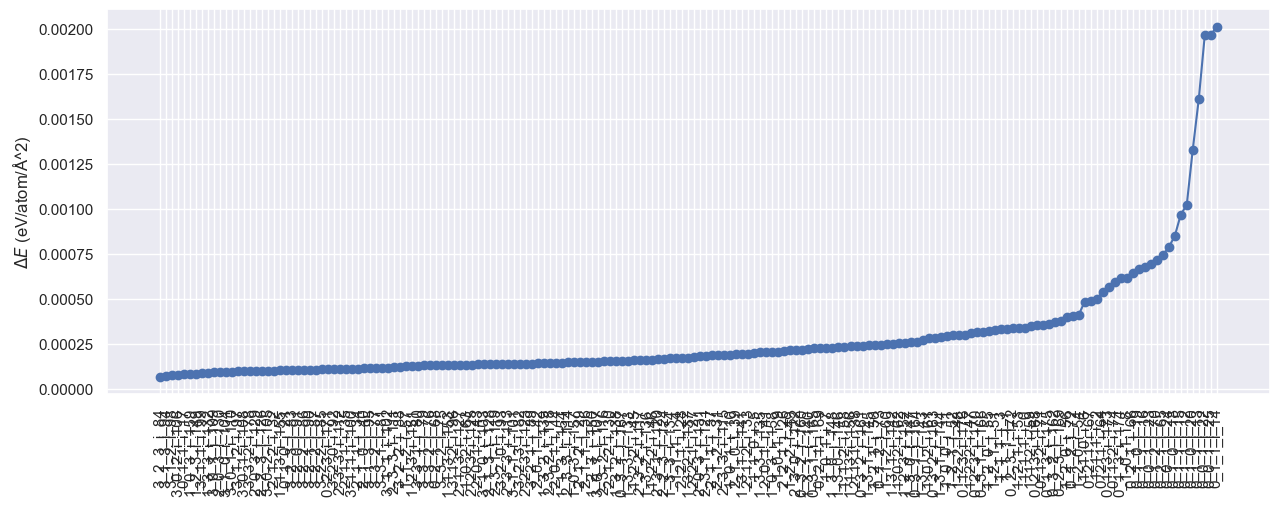

In [8]:
# Energy differences in eV/supercell
plt.figure(figsize=(15, 5))
plt.plot(energies, 'o-')
plt.xticks(range(len(local_minimas)), local_minimas, rotation='vertical')
plt.ylabel(r'$\Delta E$ (eV/atom/Å^2)')
plt.savefig(f'{slab_folder}/ranking.eps', dpi=50, bbox_inches='tight')
plt.show()